In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ecomdataset/Superstore_USA.xlsx


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Load the dataset
dataset = pd.read_excel("/kaggle/input/ecomdataset/Superstore_USA.xlsx")

In [4]:
pd.set_option('display.max_columns', None)
dataset.head(2)

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,Product Sub-Category,Product Container,Product Name,Product Base Margin,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,18606,Not Specified,0.01,2.88,0.50,2,Janice Fletcher,Regular Air,Corporate,Office Supplies,Labels,Small Box,Avery 49,0.36,Central,Illinois,Addison,60101,2012-05-28,2012-05-30,1.32,2,5.90,88525
1,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,Pens & Art Supplies,Wrap Bag,SANFORD Liquid Accent™ Tank-Style Highlighters,0.54,West,Washington,Anacortes,98221,2010-07-07,2010-07-08,4.56,4,13.01,88522


In [5]:
dataset.isnull().sum()

Row ID                   0
Order Priority           0
Discount                 0
Unit Price               0
Shipping Cost            0
Customer ID              0
Customer Name            0
Ship Mode                0
Customer Segment         0
Product Category         0
Product Sub-Category     0
Product Container        0
Product Name             0
Product Base Margin     72
Region                   0
State or Province        0
City                     0
Postal Code              0
Order Date               0
Ship Date                0
Profit                   0
Quantity ordered new     0
Sales                    0
Order ID                 0
dtype: int64

In [6]:
dataset['Product Base Margin'] = dataset['Product Base Margin'].fillna(dataset['Product Base Margin'].mean())

In [7]:
dataset['Order Priority'].value_counts()

Order Priority
High             1970
Low              1926
Not Specified    1881
Medium           1844
Critical         1804
Critical            1
Name: count, dtype: int64

In [8]:
print(dataset.head())

   Row ID Order Priority  Discount  Unit Price  Shipping Cost  Customer ID  \
0   18606  Not Specified      0.01        2.88           0.50            2   
1   20847           High      0.01        2.84           0.93            3   
2   23086  Not Specified      0.03        6.68           6.15            3   
3   23087  Not Specified      0.01        5.68           3.60            3   
4   23088  Not Specified      0.00      205.99           2.50            3   

     Customer Name    Ship Mode Customer Segment Product Category  \
0  Janice Fletcher  Regular Air        Corporate  Office Supplies   
1    Bonnie Potter  Express Air        Corporate  Office Supplies   
2    Bonnie Potter  Express Air        Corporate  Office Supplies   
3    Bonnie Potter  Regular Air        Corporate  Office Supplies   
4    Bonnie Potter  Express Air        Corporate       Technology   

            Product Sub-Category Product Container  \
0                         Labels         Small Box   
1       

In [9]:
dataset['Order Priority'].unique()

array(['Not Specified', 'High', 'Medium', 'Low', 'Critical', 'Critical '],
      dtype=object)

In [10]:
dataset['Order Priority'] = dataset["Order Priority"].replace("Critical " , "Critical")

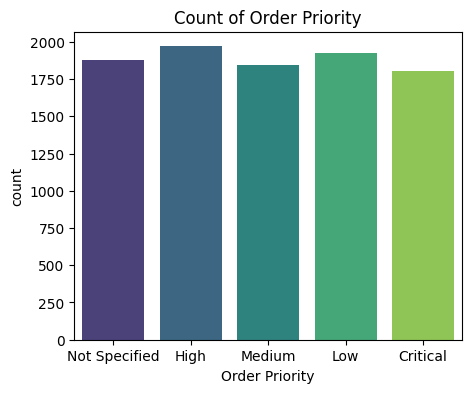

In [11]:
# Create the plot
plt.figure(figsize=(5, 4))  # Set the figure size
sns.countplot(x="Order Priority", data=dataset, palette="viridis")  # Use Seaborn's countplot
plt.title("Count of Order Priority")  # Add a title

# Save the figure as an image
plt.savefig("Count_of_Order_Priority.jpg")  # Save plot to a file
plt.show()  # Show the plot


Order Priority
High             1970
Low              1926
Not Specified    1881
Medium           1844
Critical         1805
Name: count, dtype: int64


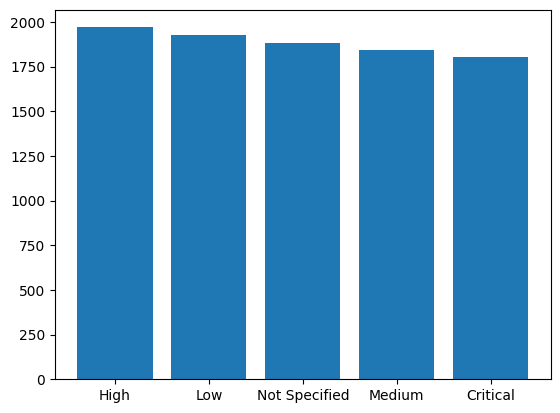

In [12]:
k = dataset["Order Priority"].value_counts()
print(k)
x = np.array(k.index)
y = np.array(k.values)

plt.bar(x,y)
plt.show()

# Ship Mode

In [13]:
dataset['Ship Mode'].value_counts()

Ship Mode
Regular Air       7036
Delivery Truck    1283
Express Air       1107
Name: count, dtype: int64

In [14]:
x = dataset['Ship Mode'].value_counts().index
y = dataset['Ship Mode'].value_counts().values

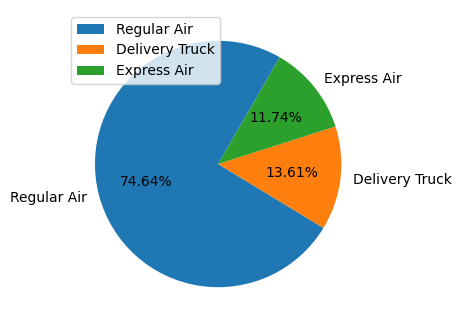

In [15]:
plt.figure(figsize=(5,4))
plt.pie(y , labels = x , startangle = 60 , autopct = "%0.2f%%")
plt.legend(loc=2)
plt.show()

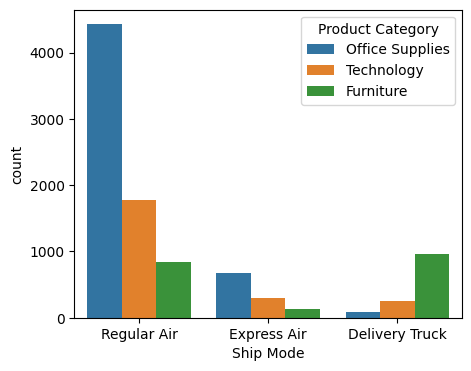

In [16]:
plt.figure(figsize = (5,4))
sns.countplot(x = 'Ship Mode' , data = dataset , hue = 'Product Category')
plt.show()

# Customer Segment

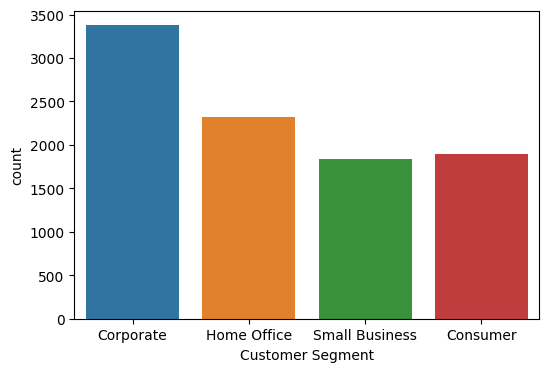

In [17]:
plt.figure(figsize = (6 , 4))
sns.countplot(x = "Customer Segment" , data = dataset)
plt.show()

# Product Category

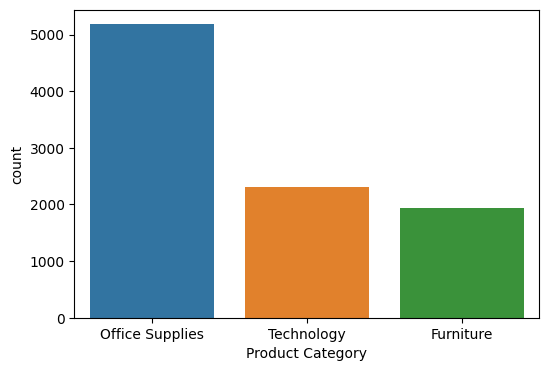

In [18]:
plt.figure(figsize = (6 , 4))
sns.countplot(x = "Product Category" , data = dataset)
plt.show()

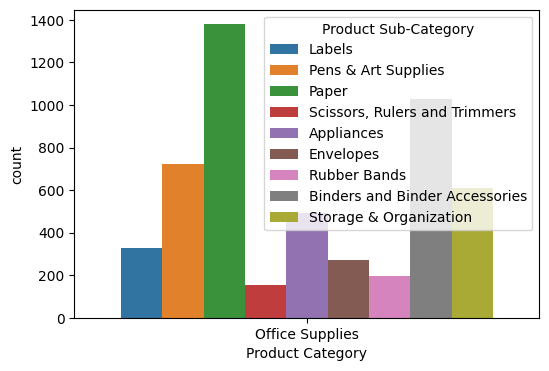

In [19]:
plt.figure(figsize = (6 , 4))
sns.countplot(x = 'Product Category' , data = dataset[dataset['Product Category']=='Office Supplies'] ,  hue = 'Product Sub-Category')
plt.show()

# Order Year

In [20]:
dataset['Order Year'] = dataset["Order Date"].dt.year

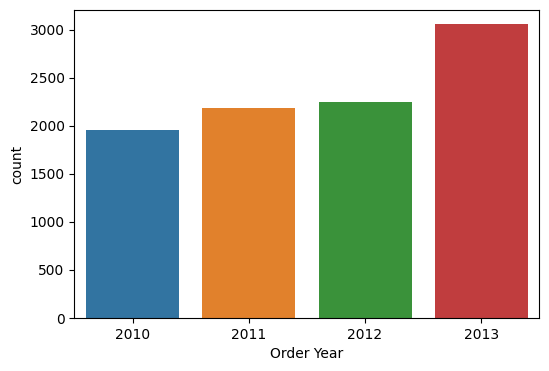

In [21]:
plt.figure(figsize = (6 , 4))
sns.countplot(x = "Order Year" , data = dataset)
plt.show()

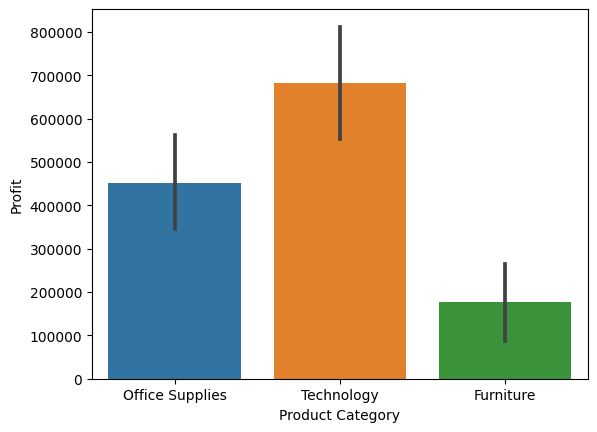

In [22]:
sns.barplot(x = 'Product Category' , y = 'Profit' , data = dataset , estimator = 'sum')
plt.show()

In [23]:
dataset['State or Province'].value_counts()[:5]

State or Province
California    1021
Texas          646
Illinois       584
New York       574
Florida        522
Name: count, dtype: int64